In [22]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from src.model import sigma_star
from src.spaces import action_on_x, action_on_z, GROUP_ELEMENTS
# N_VALUES = [5, 10, 50, 100, 500]
# N_REPS = 3
# CONFIG = {**DEFAULT_CONFIG, "T": 20.0, "gr": 5}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<unknown>:113: SyntaxWarning: invalid escape sequence '\s'
<unknown>:113: SyntaxWarning: invalid escape sequence '\s'


In [29]:
#Test whether the new sigma is equivariant.
z = jnp.array([[23., 21.],
               [34., 56.]])
x = jnp.array([1., 2.])
print(f'sigma(rho.x, M.z) = {sigma_star(action_on_x(GROUP_ELEMENTS[1], x), action_on_z(GROUP_ELEMENTS[1], z))}')
print(f'rho*sigma(z, x) = {action_on_x(GROUP_ELEMENTS[1], sigma_star(x, z))}')

sigma(rho.x, M.z) = [56. 34.]
rho*sigma(z, x) = [56. 34.]


<unknown>:113: SyntaxWarning: invalid escape sequence '\s'


In [21]:
z[:, 1]

Array([21., 56.], dtype=float32)

Training UV + WI teacher (N=5)...
Training UV + arbitrary teacher (N=5)...


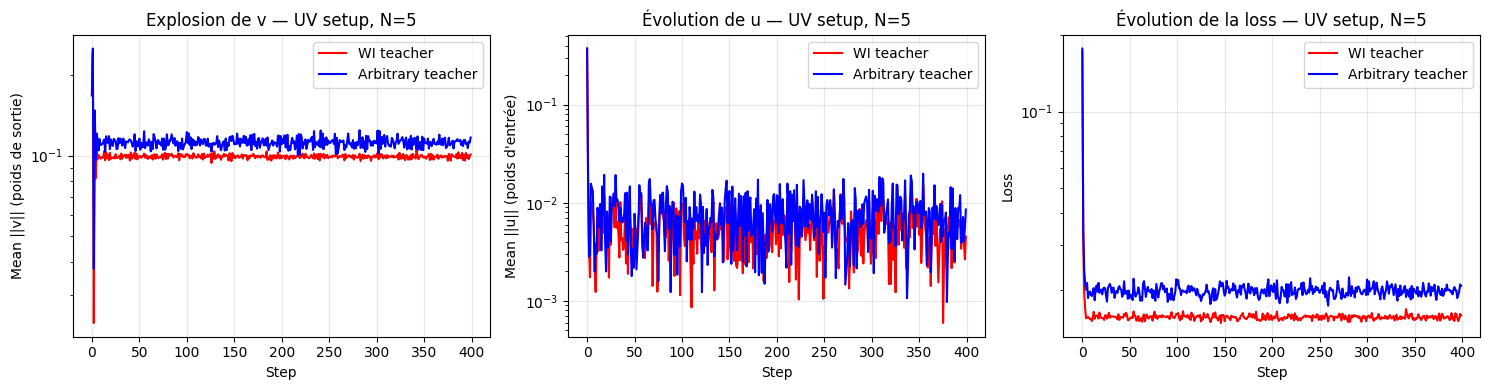

||v|| final — WI: 0.101,  arbitrary: 0.117
||u|| final — WI: 0.005,  arbitrary: 0.009
loss  final — WI: 0.016, arbitrary: 0.021


In [8]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import src.spaces as spaces
spaces.SETUP = spaces.make_setup_uv()
jax.clear_caches()  # évite de réutiliser un cache JIT compilé avec un autre setup

from src.training import loss_fn, init_particles_si, sgd_step
from src.teacher import make_wi_particles, make_arbitrary_particles, sample_data

N   = 5
Ne  = 400
cfg = {'alpha': 5.0, 'tau': 0.5, 'beta': 1e-6, 'batch_size': 20}

def track_norms(teacher, N, Ne, cfg, seed=0):
    """Entraîne N particules (SI init, UV setup) et retourne
    l'évolution de ||v||, ||u|| et de la loss à chaque step."""
    key = jax.random.PRNGKey(seed)
    key, init_key = jax.random.split(key)
    particles = init_particles_si(init_key, N)

    v_norms, u_norms, losses = [], [], []

    for k in range(Ne):
        key, data_key, noise_key = jax.random.split(key, 3)
        x_batch, y_batch = sample_data(data_key, teacher, cfg['batch_size'])

        losses.append(float(loss_fn(particles, x_batch, y_batch, cfg['tau'])))
        v_norms.append(float(jnp.mean(jnp.linalg.norm(particles[:, 1, :], axis=-1))))
        u_norms.append(float(jnp.mean(jnp.linalg.norm(particles[:, 0, :], axis=-1))))

        particles = sgd_step(
            particles, x_batch, y_batch, noise_key,
            cfg['alpha'], cfg['tau'], cfg['beta'],
            loss_fn, True,
        )

    return v_norms, u_norms, losses

print('Training UV + WI teacher (N=5)...')
v_wi,  u_wi,  loss_wi  = track_norms(make_wi_particles(),       N, Ne, cfg, seed=0)
print('Training UV + arbitrary teacher (N=5)...')
v_arb, u_arb, loss_arb = track_norms(make_arbitrary_particles(), N, Ne, cfg, seed=0)

steps = list(range(Ne))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(steps, v_wi,  label='WI teacher',        color='red')
axes[0].plot(steps, v_arb, label='Arbitrary teacher', color='blue')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Mean ||v|| (poids de sortie)')
axes[0].set_title('Explosion de v — UV setup, N=5')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, u_wi,  label='WI teacher',        color='red')
axes[1].plot(steps, u_arb, label='Arbitrary teacher', color='blue')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Mean ||u|| (poids d\'entrée)')
axes[1].set_title('Évolution de u — UV setup, N=5')
axes[1].set_yscale('log'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, loss_wi,  label='WI teacher',        color='red')
axes[2].plot(steps, loss_arb, label='Arbitrary teacher', color='blue')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Loss')
axes[2].set_title('Évolution de la loss — UV setup, N=5')
axes[2].set_yscale('log'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'||v|| final — WI: {v_wi[-1]:.3f},  arbitrary: {v_arb[-1]:.3f}')
print(f'||u|| final — WI: {u_wi[-1]:.3f},  arbitrary: {u_arb[-1]:.3f}')
print(f'loss  final — WI: {loss_wi[-1]:.3f}, arbitrary: {loss_arb[-1]:.3f}')
